# Step 3 — The Dixon-Coles goals model

**Goal:** predict the **scoreline**, not just the winner. Each team gets an **attack** strength and a **defence** strength, and goals are modelled with the Poisson distribution we checked in Step 1.

**The model** (Dixon & Coles, 1997):
- Home goals ~ Poisson(λ), away goals ~ Poisson(μ)
- `log λ = intercept + home advantage + attack(home team) + defence(away team)`
- `log μ = intercept + attack(away team) + defence(home team)`
- In this notebook, a **higher defence number means a leakier defence** (the team concedes more).
- A correction factor **ρ (rho)** adjusts the four low scores 0–0, 1–0, 0–1 and 1–1, which plain Poisson gets wrong (the 0–0 effect from Step 1).

**Two more ideas:**
- **Time weighting:** recent matches matter more. A match from 2 years ago counts half as much as one played today (a "half-life" of 2 years).
- **Two-step fitting:** first we fit attack, defence and home advantage with a Poisson regression; then we find the ρ that best explains the low scores. This is a common, fast approximation of the full method.

## 1. Setup

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 4)

# Save everything in Google Drive, so each notebook can use the previous notebook's outputs.
# Colab will ask for permission to access your Drive the first time.
try:
    from google.colab import drive
    drive.mount("/content/drive")
    BASE = "/content/drive/MyDrive/world-cup-prediction"
except ImportError:          # running on your own computer instead of Colab
    BASE = "."
os.makedirs(BASE, exist_ok=True)
os.chdir(BASE)
for folder in ["data", "models", "preds"]:
    os.makedirs(folder, exist_ok=True)
print("Working folder:", os.getcwd())

Mounted at /content/drive
Working folder: /content/drive/MyDrive/world-cup-prediction


In [2]:
URL = "https://raw.githubusercontent.com/martj42/international_results/master/results.csv"
START_YEAR = 1990

def load_matches():
    """Load cleaned matches (downloading and cleaning them first if needed)."""
    path = "data/matches_clean.csv"
    if not os.path.exists(path):
        raw = pd.read_csv(URL, parse_dates=["date"])
        df = raw.dropna(subset=["home_score", "away_score"])
        df = df[df["date"].dt.year >= START_YEAR].copy()
        df.to_csv(path, index=False)
    df = pd.read_csv(path, parse_dates=["date"])
    df = df.sort_values(["date", "home_team", "away_team"], kind="stable").reset_index(drop=True)
    df["match_id"] = df.index
    df["home_score"] = df["home_score"].astype(int)
    df["away_score"] = df["away_score"].astype(int)
    df["neutral"] = df["neutral"].astype(bool)
    # Result coded as a class: 0 = home win, 1 = draw, 2 = away win
    df["result"] = np.select([df["home_score"] > df["away_score"],
                              df["home_score"] < df["away_score"]], [0, 2], default=1)
    return df

def add_splits(df):
    """train: before 2024 | val: 2024 until the World Cup | test: the 2026 World Cup matches."""
    wc26 = (df["tournament"] == "FIFA World Cup") & (df["date"].dt.year == 2026)
    test_start = df.loc[wc26, "date"].min() if wc26.any() else pd.Timestamp("2026-06-11")
    val_start = pd.Timestamp("2024-01-01")
    df["split"] = np.select([df["date"] < val_start, df["date"] < test_start, wc26],
                            ["train", "val", "test"], default="after")
    return df, val_start, test_start

matches, VAL_START, TEST_START = add_splits(load_matches())
print(matches["split"].value_counts().to_string())
print("Validation starts:", VAL_START.date(), "| Test (World Cup 2026) starts:", TEST_START.date())

split
train    29787
val       2564
after      366
test       104
Validation starts: 2024-01-01 | Test (World Cup 2026) starts: 2026-06-11


## Train / validation / test split

To judge the models honestly, they must be tested on matches they have **never seen**:

| Split | Matches | Used for |
| --- | --- | --- |
| **train** | before 2024 | fitting the models |
| **val** | 2024 → start of World Cup 2026 | comparing models and tuning settings |
| **test** | the 2026 World Cup itself | the final, one-time exam |

Splitting by **time** (not randomly) matters in sport: a model must never learn from the future.

## 2. Fit the model

In [3]:
from scipy import sparse
from scipy.optimize import minimize_scalar
from scipy.stats import poisson
from sklearn.linear_model import PoissonRegressor

def tau(x, y, lam, mu, rho):
    """Dixon-Coles low-score correction."""
    t = np.ones_like(lam, dtype=float)
    t = np.where((x == 0) & (y == 0), 1 - lam * mu * rho, t)
    t = np.where((x == 0) & (y == 1), 1 + lam * rho, t)
    t = np.where((x == 1) & (y == 0), 1 + mu * rho, t)
    t = np.where((x == 1) & (y == 1), 1 - rho, t)
    return np.clip(t, 1e-10, None)

def fit_dixon_coles(df, cutoff, years=8, half_life_days=730, alpha=1e-4):
    """Fit on matches in the `years` before `cutoff`. Uses nothing on or after the cutoff."""
    fit = df[(df["date"] < cutoff) & (df["date"] >= cutoff - pd.DateOffset(years=years))]
    teams = sorted(set(fit["home_team"]) | set(fit["away_team"]))
    idx = {t: i for i, t in enumerate(teams)}
    n, m = len(teams), len(fit)
    hi, ai = fit["home_team"].map(idx).values, fit["away_team"].map(idx).values
    home_flag = (~fit["neutral"]).astype(float).values

    # Two rows per match: home goals, then away goals.
    # Columns: [attack of each team | defence of each team | home advantage]
    rows = np.arange(2 * m)
    X = sparse.csr_matrix(
        (np.concatenate([np.ones(4 * m), home_flag]),
         (np.concatenate([rows, rows, np.arange(m)]),
          np.concatenate([hi, ai, ai + n, hi + n, np.full(m, 2 * n)]))),
        shape=(2 * m, 2 * n + 1))
    y = np.concatenate([fit["home_score"].values, fit["away_score"].values])
    days_ago = (cutoff - fit["date"]).dt.days.values
    w = 0.5 ** (days_ago / half_life_days)

    glm = PoissonRegressor(alpha=alpha, max_iter=3000).fit(X, y, sample_weight=np.concatenate([w, w]))
    att, dfn, home = glm.coef_[:n], glm.coef_[n:2 * n], glm.coef_[2 * n]
    intercept = glm.intercept_

    # Step 2: choose rho to best explain the low scores
    lam = np.exp(intercept + home * home_flag + att[hi] + dfn[ai])
    mu = np.exp(intercept + att[ai] + dfn[hi])
    x_obs, y_obs = fit["home_score"].values, fit["away_score"].values
    rho = minimize_scalar(lambda r: -np.sum(w * np.log(tau(x_obs, y_obs, lam, mu, r))),
                          bounds=(-0.3, 0.3), method="bounded").x

    return {"teams": teams, "att": att.tolist(), "def": dfn.tolist(), "intercept": float(intercept),
            "home": float(home), "rho": float(rho), "cutoff": str(cutoff.date()), "n_matches": int(m)}

We fit **two versions**, each using only the data available at that time:
- **Model A**, fitted on matches before the validation period, to predict validation matches.
- **Model B**, fitted on everything before the World Cup, to predict World Cup matches.

In [4]:
params_val = fit_dixon_coles(matches, VAL_START)
params_test = fit_dixon_coles(matches, TEST_START)

for name, p in [("Model A (validation)", params_val), ("Model B (World Cup)", params_test)]:
    print(f"{name}: {p['n_matches']:,} matches | home advantage x{np.exp(p['home']):.2f} goals"
          f" | rho = {p['rho']:.3f}")

Model A (validation): 7,440 matches | home advantage x1.30 goals | rho = -0.021
Model B (World Cup): 7,822 matches | home advantage x1.26 goals | rho = -0.051


**Reading the numbers:**
- A home advantage of e.g. ×1.3 means the home team scores about 30% more goals than at a neutral venue.
- A **negative ρ** means 0–0 and 1–1 are *more* likely than plain Poisson predicts, which matches what we saw in Step 1.

## 3. Who has the best attack and defence?

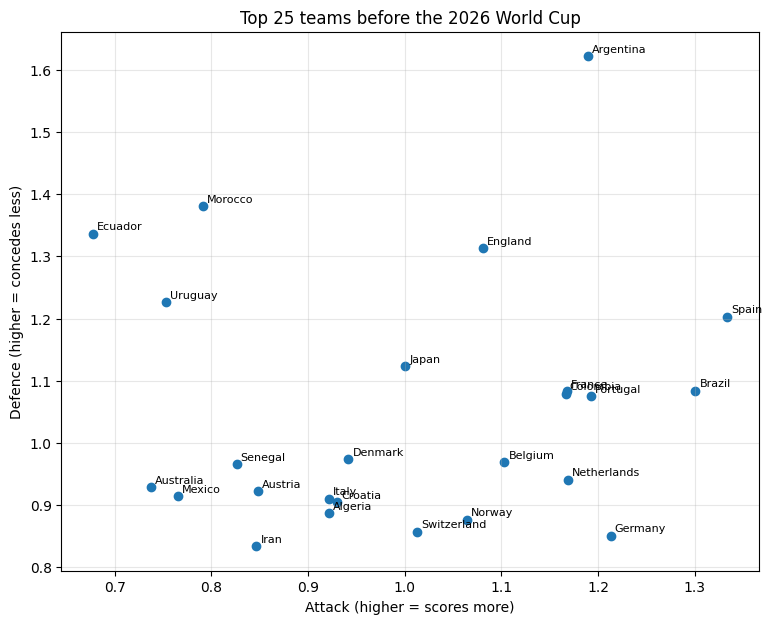

In [5]:
strength = pd.DataFrame({"team": params_test["teams"], "attack": params_test["att"],
                         "defence": params_test["def"]})
strength["overall"] = strength["attack"] - strength["defence"]
top = strength.nlargest(25, "overall")

plt.figure(figsize=(9, 7))
plt.scatter(top["attack"], -top["defence"])
for _, r in top.iterrows():
    plt.annotate(r["team"], (r["attack"], -r["defence"]), fontsize=8, xytext=(3, 3), textcoords="offset points")
plt.xlabel("Attack (higher = scores more)")
plt.ylabel("Defence (higher = concedes less)")
plt.title("Top 25 teams before the 2026 World Cup")
plt.grid(alpha=0.3); plt.show()

## 4. Predict scorelines

In [6]:
def dc_score_matrix(params, home, away, neutral=True, max_goals=10):
    """Probability of every scoreline from 0-0 to 10-10."""
    idx = {t: i for i, t in enumerate(params["teams"])}
    get = lambda key, team: params[key][idx[team]] if team in idx else 0.0   # unknown team = average
    lam = np.exp(params["intercept"] + (0 if neutral else params["home"]) + get("att", home) + get("def", away))
    mu = np.exp(params["intercept"] + get("att", away) + get("def", home))
    g = np.arange(max_goals + 1)
    M = np.outer(poisson.pmf(g, lam), poisson.pmf(g, mu))
    rho = params["rho"]
    M[0, 0] *= 1 - lam * mu * rho
    M[0, 1] *= 1 + lam * rho
    M[1, 0] *= 1 + mu * rho
    M[1, 1] *= 1 - rho
    return M / M.sum(), lam, mu

def dc_probs(M):
    """Home win / draw / away win from the scoreline matrix (rows = home goals)."""
    return np.tril(M, -1).sum(), np.trace(M), np.triu(M, 1).sum()

In [7]:
# Example: the first match of the 2026 World Cup
first = matches[matches["split"] == "test"].iloc[0] if (matches["split"] == "test").any() else matches.iloc[-1]
M_ex, lam_ex, mu_ex = dc_score_matrix(params_test, first["home_team"], first["away_team"], first["neutral"])
print(f"{first['home_team']} vs {first['away_team']}: expected goals {lam_ex:.2f} – {mu_ex:.2f}")
print("Win / draw / loss: " + " / ".join(f"{p:.1%}" for p in dc_probs(M_ex)))
top5 = sorted(((M_ex[i, j], f"{i}-{j}") for i in range(6) for j in range(6)), reverse=True)[:5]
print("Most likely scores:", ", ".join(f"{s} ({p:.1%})" for p, s in top5))
print(f"Actual result: {first['home_score']}-{first['away_score']}")

Mexico vs South Africa: expected goals 1.78 – 0.63
Win / draw / loss: 64.6% / 23.3% / 12.1%
Most likely scores: 1-0 (15.4%), 2-0 (14.2%), 1-1 (10.6%), 0-0 (9.5%), 2-1 (9.0%)
Actual result: 2-0


## 5. Evaluate on the validation set and save

In [8]:
from sklearn.metrics import log_loss

rows = []
for split, params in [("val", params_val), ("test", params_test)]:
    for r in matches[matches["split"] == split].itertuples(index=False):
        M_, lam, mu = dc_score_matrix(params, r.home_team, r.away_team, r.neutral)
        ph, pd_, pa = dc_probs(M_)
        rows.append({"match_id": r.match_id, "p_home": ph, "p_draw": pd_, "p_away": pa,
                     "exp_home_goals": lam, "exp_away_goals": mu})
dc_preds = pd.DataFrame(rows)

val = matches[matches["split"] == "val"].merge(dc_preds, on="match_id")
print(f"Dixon-Coles validation log loss: "
      f"{log_loss(val['result'], val[['p_home', 'p_draw', 'p_away']].values, labels=[0, 1, 2]):.4f}")

dc_preds.to_csv("preds/dc_preds.csv", index=False)
json.dump(params_val, open("models/dc_params_val.json", "w"))
json.dump(params_test, open("models/dc_params_test.json", "w"))
print("Saved Dixon-Coles predictions and parameters.")

Dixon-Coles validation log loss: 0.8615
Saved Dixon-Coles predictions and parameters.
